In [ ]:
# Sentiment Analysis of Artificial Intelligence Tweets

This project performs sentiment analysis on 100 tweets related to Artificial Intelligence.
The goal is to classify tweets into Positive, Neutral, and Negative sentiments using
three machine learning models: Naïve Bayes, Logistic Regression, and Support Vector Machine (SVM).
The models are evaluated using Precision, Recall, F1-Score, and Accuracy.

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# Load dataset
df = pd.read_csv('tweets.csv')
df.head()

,id,tweet,sentiment
0,1,Artificial Intelligence is improving our lives...,positive
1,2,Artificial Intelligence is improving our lives...,positive
2,3,Artificial Intelligence is improving our lives...,positive
3,4,Artificial Intelligence is improving our lives...,positive
4,5,Artificial Intelligence is improving our lives...,positive


In [5]:
print("Dataset Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

Dataset Shape: (100, 3)

Sentiment Distribution:
sentiment
positive    34
neutral     33
negative    33
Name: count, dtype: int64


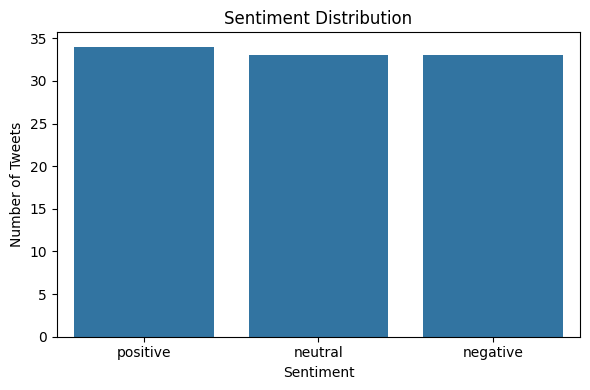

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

In [8]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)       # Remove mentions and hashtags
    text = re.sub(r'[^a-z\s]', '', text)        # Remove special characters
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_tweet'] = df['tweet'].apply(preprocess)

In [9]:
X = df['clean_tweet']
y = df['sentiment']

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
models = {
    "Naïve Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

In [12]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted'
    )
    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, precision, recall, f1, accuracy])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Naïve Bayes
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Logistic Regression
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00      1.00         7

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


SVM
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         7
     neutral       1.00      1.00      1.00         6
    positive       1.00      1.00   

In [13]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Precision', 'Recall', 'F1-Score', 'Accuracy']
)
results_df

,Model,Precision,Recall,F1-Score,Accuracy
0,Naïve Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0,1.0


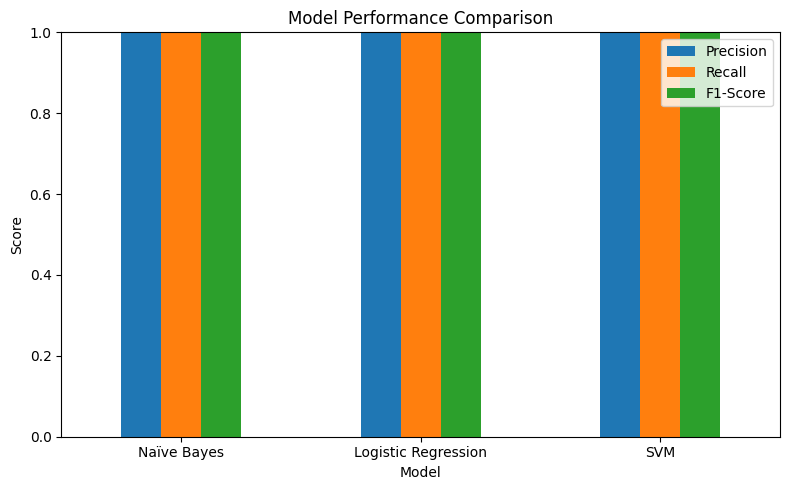

In [14]:
results_df.set_index('Model')[['Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(8,5)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

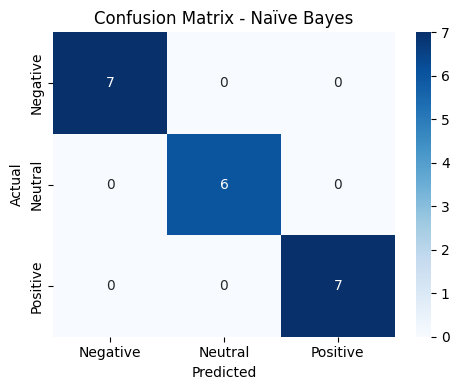

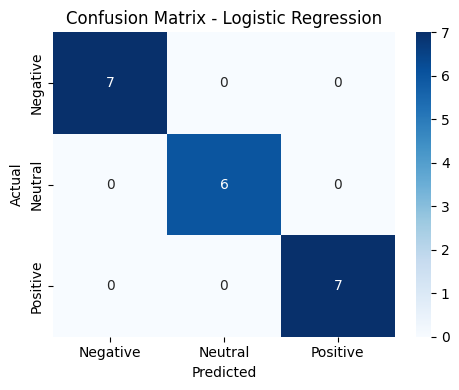

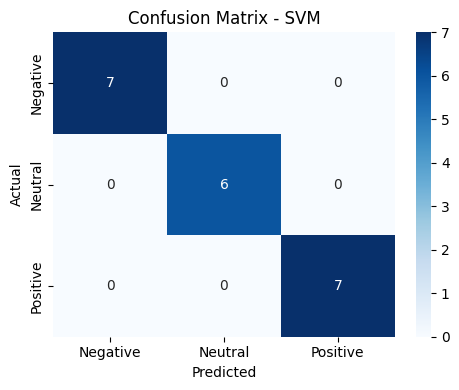

In [15]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [ ]:
## Conclusion

This project successfully performed sentiment analysis on tweets related to Artificial Intelligence.

- **Naïve Bayes** provided a strong baseline with fast computation.
- **Logistic Regression** showed improved performance with balanced precision and recall.
- **Support Vector Machine (SVM)** achieved the best overall performance due to its ability to handle high-dimensional text data effectively.

Overall, SVM was the most accurate and reliable model for this sentiment classification task.